

# Plotting whitened data

This tutorial demonstrates how to plot :term:`whitened <whitening>` evoked data.

Data are whitened for many processes, including dipole fitting, source
localization and some decoding algorithms. Viewing whitened data thus gives
a different perspective on the data that these algorithms operate on.

Let's start by loading some data and computing a signal (spatial) covariance
that we'll consider to be noise.


In [1]:
# Authors: The MNE-Python contributors.
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

In [2]:
import mne
from mne.datasets import sample

## Raw data with whitening
<div class="alert alert-info"><h4>Note</h4><p>In the :meth:`mne.io.Raw.plot` with ``noise_cov`` supplied,
          you can press they "w" key to turn whitening on and off.</p></div>



In [3]:
data_path = sample.data_path()
raw_fname = data_path / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
raw = mne.io.read_raw_fif(raw_fname, preload=True)

events = mne.find_events(raw, stim_channel="STI 014")
event_id = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
    "smiley": 5,
    "button": 32,
}
reject = dict(grad=4000e-13, mag=4e-12, eog=150e-6)
epochs = mne.Epochs(raw, events, event_id=event_id, reject=reject)

# baseline noise cov, not a lot of samples
noise_cov = mne.compute_covariance(
    epochs, tmax=0.0, method="shrunk", rank=None, verbose="error"
)

# butterfly mode shows the differences most clearly
raw.plot(events=events, butterfly=True)
raw.plot(noise_cov=noise_cov, events=events, butterfly=True)

Opening raw data file /home/jshen/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
Reading 0 ... 41699  =      0.000 ...   277.709 secs...
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
319 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Using qt as 2D backend.


QStandardPaths: wrong permissions on runtime directory /run/user/1000/, 0755 instead of 0700


Computing rank from covariance with rank=None
    Using tolerance 8.3e-14 (2.2e-16 eps * 59 dim * 6.3  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 (2.2e-16 eps * 203 dim * 4.3  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.7e-14 (2.2e-16 eps * 102 dim * 1.2  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors


## Epochs with whitening



In [4]:
epochs.plot(events=True)
epochs.plot(noise_cov=noise_cov, events=True)

Using data from preloaded Raw for 319 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejec

## Evoked data with whitening



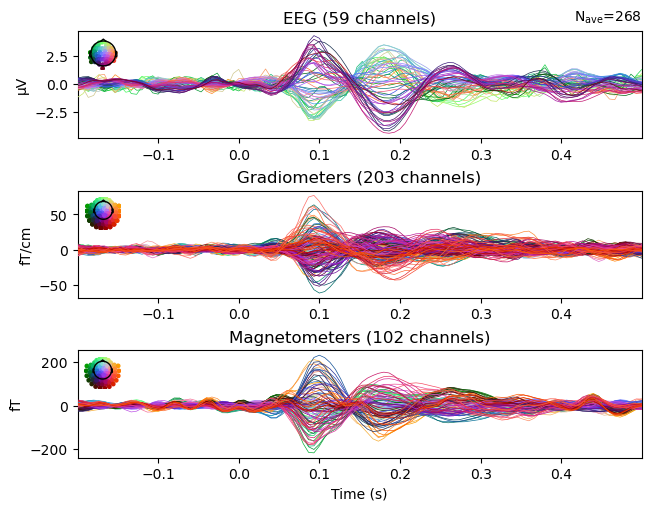

Computing rank from covariance with rank=None
    Using tolerance 8.3e-14 (2.2e-16 eps * 59 dim * 6.3  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 (2.2e-16 eps * 203 dim * 4.3  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.7e-14 (2.2e-16 eps * 102 dim * 1.2  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors


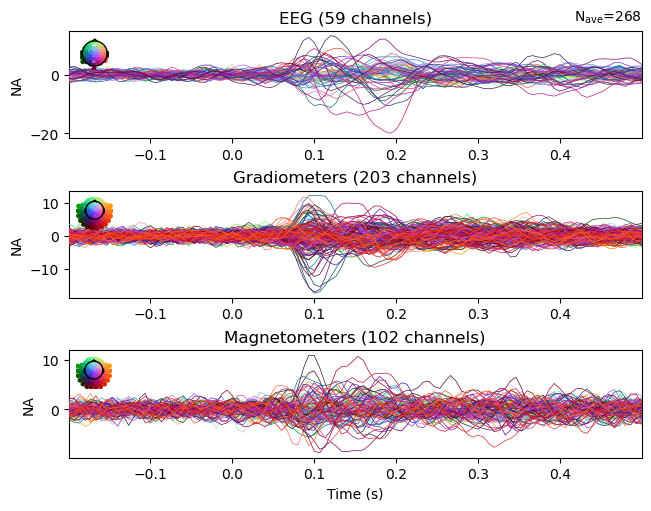

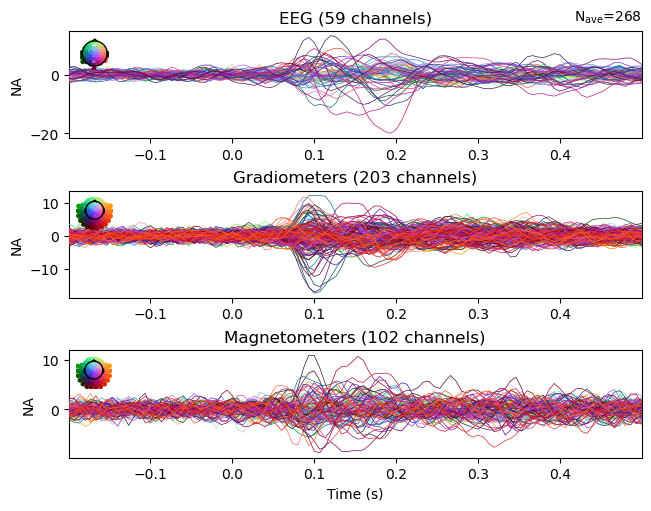

In [5]:
evoked = epochs.average()
evoked.plot(time_unit="s")
evoked.plot(noise_cov=noise_cov, time_unit="s")

## Evoked data with scaled whitening
The :meth:`mne.Evoked.plot_white` function takes an additional step of
scaling the whitened plots to show how well the assumption of Gaussian
noise is satisfied by the data:



NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 8.3e-14 (2.2e-16 eps * 59 dim * 6.3  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 (2.2e-16 eps * 203 dim * 4.3  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.7e-14 (2.2e-16 eps * 102 dim * 1.2  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors
    Created an SSP operator (subspace dimension = 4)
Computing rank from covariance with rank={'eeg': 58, 'grad': 203, 'mag': 99, 'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
    Setting small EEG eigenvalues to zero (without PCA)
    Crea

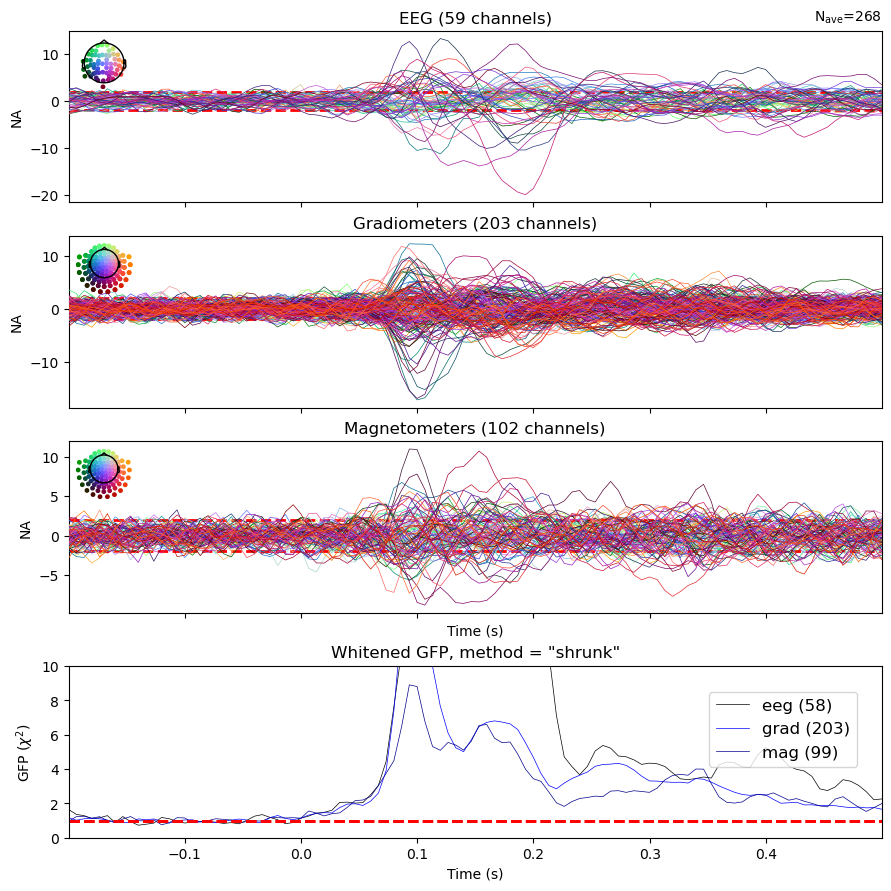

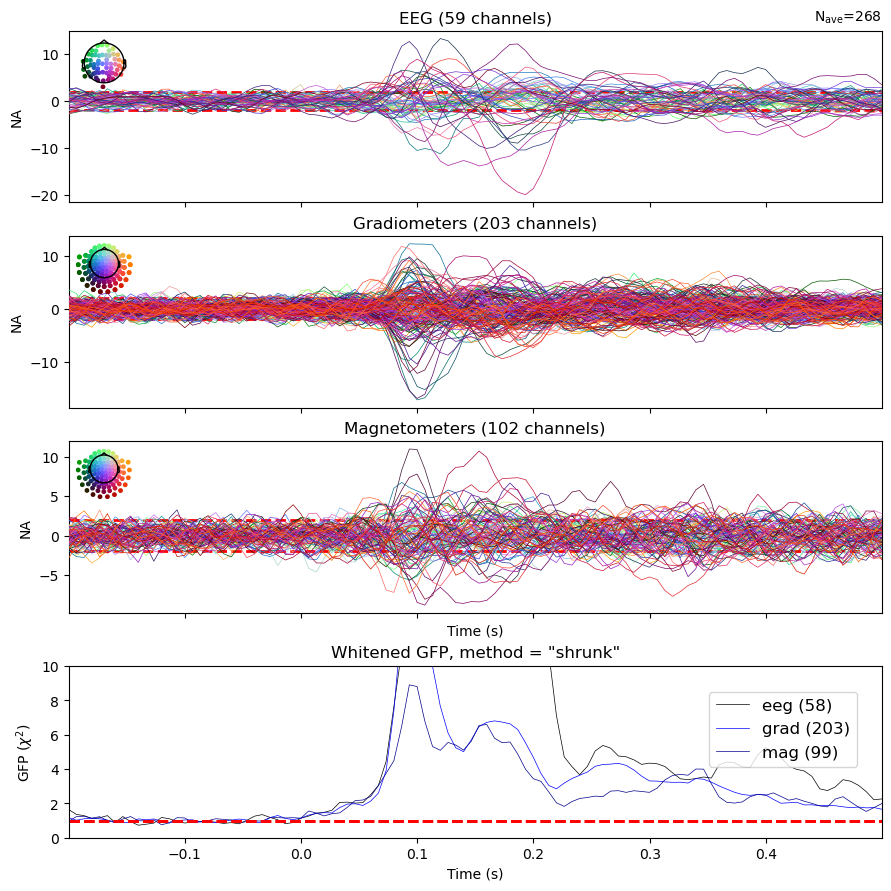

In [6]:
evoked.plot_white(noise_cov=noise_cov, time_unit="s")

## Topographic plot with whitening



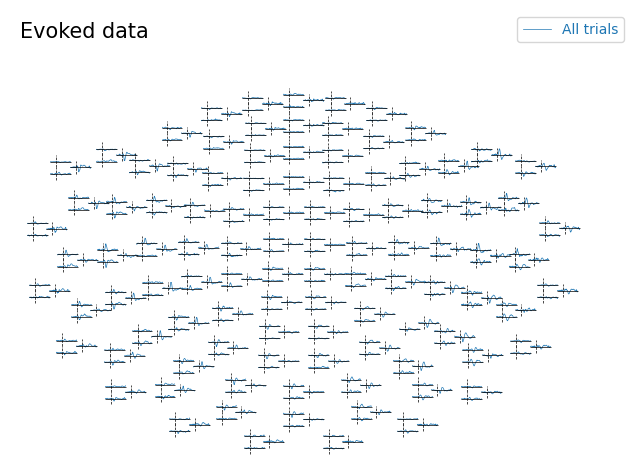

    Created an SSP operator (subspace dimension = 4)
Computing rank from covariance with rank=None
    Using tolerance 3.6e-13 (2.2e-16 eps * 305 dim * 5.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Using tolerance 8.3e-14 (2.2e-16 eps * 59 dim * 6.3  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
    Setting small MEG eigenvalues to zero (without PCA)
    Setting small EEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 360 (4 small eigenvalues omitted)


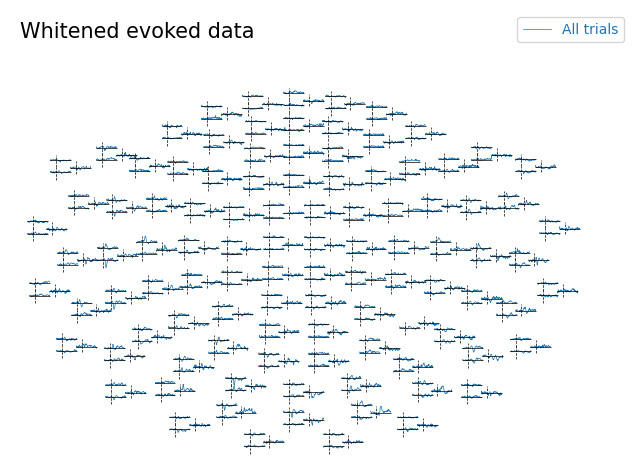

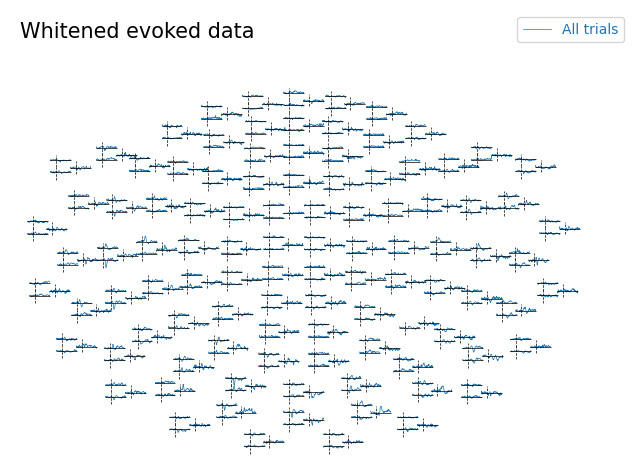

Channels marked as bad:
['MEG 2443', 'EEG 053']
Computing rank from covariance with rank=None
    Using tolerance 8.3e-14 (2.2e-16 eps * 59 dim * 6.3  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 (2.2e-16 eps * 203 dim * 4.3  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.7e-14 (2.2e-16 eps * 102 dim * 1.2  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors
Computing rank from covariance with rank=None
    Using tolerance 8.3e-14 (2.2e-16 eps * 59 dim * 6.3  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 

In [ ]:
evoked.comment = "All trials"
evoked.plot_topo(title="Evoked data")
evoked.plot_topo(noise_cov=noise_cov, title="Whitened evoked data")